# credit scoring model

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

## Load Dataset

In [3]:
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

## Data Cleaning
### Data Exploration

In [4]:
df_train

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
0,27010017245,10720596,585913,M,F,0.0,0,N,Semi-urban,G,N
1,27010017436,43455000,585913,M,F,0.0,0,N,Semi-urban,G,N
2,27010017458,22012402,68348,M,F,0.0,2744483,N,Rural,G,N
3,27010017493,4893983,0,M,M,0.0,0,N,Semi-urban,G,N
4,27010017515,46254814,68348,M,F,0.0,0,N,Rural,G,N
...,...,...,...,...,...,...,...,...,...,...,...
37403,1598330000653,515150,2869,M,M,24583.0,67350,Y,Rural,G,N
37404,1598330000664,515150,1771,M,M,24583.0,71250,Y,Rural,G,N
37405,1598350000352,764375,1356,M,M,0.0,0,Y,Rural,G,N
37406,1598350000431,1268625,52310,M,M,0.0,111975,Y,Rural,G,N


In [5]:
df_test

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
0,1598350000464,641740,1038,M,M,0.0,400000,N,Rural,G,N
1,1598350000475,532125,4310,M,M,0.0,414560,N,Rural,G,N
2,1598350000486,632625,4310,M,M,0.0,312891,N,Rural,G,N
3,1598350000622,1967250,5114,M,M,0.0,0,N,Rural,G,N
4,1598350000655,1636875,2787,M,M,0.0,0,N,Rural,G,N
...,...,...,...,...,...,...,...,...,...,...,...
4305,2068190000018,2711563,122498,M,M,0.0,0,N,Rural,G,N
4306,2068400000034,515411,41,M,M,0.0,19395,N,Rural,G,I
4307,2068400000045,541072,305,M,M,0.0,12546,N,Rural,G,I
4308,2068400000067,541232,0,M,M,0.0,12386,N,Rural,G,I


In [6]:
df_train.columns

Index(['ACC_NO', 'INVESTMENT_TOTAL', 'ACCCURRENTBALANCE', 'INF_MARITAL_STATUS',
       'INF_GENDER', 'INSTALL_SIZE', 'DUE_PAYMENT', 'COMPENSATION_CHARGED',
       'CLIENT_TYPE', 'QUALITY_OF_LOAN', 'REPAY_MODE'],
      dtype='str')

In [7]:
for col in df_train.columns:
    print(col, df_train[col].unique()[:10])

ACC_NO [27010017245 27010017436 27010017458 27010017493 27010017515 27010017537
 27010017548 27010017559 27010017572 27010017627]
INVESTMENT_TOTAL [10720596 43455000 22012402  4893983 46254814 54562500 21825000 10912500
 11299894 11310806]
ACCCURRENTBALANCE [ 585913   68348       0  101223 1043874 1451300  192461  407013  288508
   28434]
INF_MARITAL_STATUS <ArrowStringArray>
['M', 'U', 'O', nan]
Length: 4, dtype: str
INF_GENDER <ArrowStringArray>
['F', 'M', nan, 'O']
Length: 4, dtype: str
INSTALL_SIZE [      0.   20151.   63693.   63786.  183897.  183947.  178820.  178823.
   75686. 1931622.]
DUE_PAYMENT [       0  2744483 27763183 49596472    28556  5460389 10001000 32438000
  1346037 39143350]
COMPENSATION_CHARGED <ArrowStringArray>
['N', 'Y', nan]
Length: 3, dtype: str
CLIENT_TYPE <ArrowStringArray>
['Semi-urban', 'Rural', 'Urban', nan, '0']
Length: 5, dtype: str
QUALITY_OF_LOAN <ArrowStringArray>
['G', 'B']
Length: 2, dtype: str
REPAY_MODE <ArrowStringArray>
['N', 'I']
Length: 2, 

In [8]:
df_train.shape

(37408, 11)

In [9]:
df_train.info

<bound method DataFrame.info of               ACC_NO  INVESTMENT_TOTAL  ACCCURRENTBALANCE INF_MARITAL_STATUS  \
0        27010017245          10720596             585913                  M   
1        27010017436          43455000             585913                  M   
2        27010017458          22012402              68348                  M   
3        27010017493           4893983                  0                  M   
4        27010017515          46254814              68348                  M   
...              ...               ...                ...                ...   
37403  1598330000653            515150               2869                  M   
37404  1598330000664            515150               1771                  M   
37405  1598350000352            764375               1356                  M   
37406  1598350000431           1268625              52310                  M   
37407  1598350000442           1159500              52310                  M   

      I

### Missing Values

In [10]:
df_train.isnull().sum()

ACC_NO                    0
INVESTMENT_TOTAL          0
ACCCURRENTBALANCE         0
INF_MARITAL_STATUS        2
INF_GENDER                2
INSTALL_SIZE            838
DUE_PAYMENT               0
COMPENSATION_CHARGED      2
CLIENT_TYPE             103
QUALITY_OF_LOAN           0
REPAY_MODE                0
dtype: int64

### Remove Identifier

In [11]:
df_train.drop("ACC_NO",inplace = True,axis= 1)
df_test.drop("ACC_NO",inplace = True,axis= 1)

### Categorical and Numerical Features

In [12]:
cat_cols = [
    "INF_MARITAL_STATUS",
    "CLIENT_TYPE",
    "INF_GENDER",
    "COMPENSATION_CHARGED",
    "REPAY_MODE"
]

numeric_cols = [
    "INVESTMENT_TOTAL",
    "ACCCURRENTBALANCE",
    "INSTALL_SIZE",
    "DUE_PAYMENT"
]

for col in cat_cols :
    df_train[col] = df_train[col].fillna(
        df_train[col].mode()[0]
    )

for col in cat_cols :
    df_test[col] = df_test[col].fillna(
        df_test[col].mode()[0]
    )



## Skewness Analysis and Log Transformation

In [13]:
# Before log transformation
print("Before:")
print(df_train[numeric_cols].skew())

# Log transformation
for col in numeric_cols:
    df_train[col + "_log"] = np.log1p(df_train[col])
    df_test[col + "_log"] = np.log1p(df_test[col])

# Log-transformed columns
log_cols = [col + "_log" for col in numeric_cols]

# After log transformation
print("\nAfter:")
print(df_train[log_cols].skew())

Before:
INVESTMENT_TOTAL     28.398156
ACCCURRENTBALANCE    13.907121
INSTALL_SIZE         63.939017
DUE_PAYMENT          41.823283
dtype: float64

After:
INVESTMENT_TOTAL_log     1.053869
ACCCURRENTBALANCE_log   -0.652241
INSTALL_SIZE_log         1.881198
DUE_PAYMENT_log          1.971464
dtype: float64


In [14]:
df_train.drop(columns=numeric_cols, inplace=True)
df_test.drop(columns=numeric_cols, inplace=True)

In [15]:
df_train[log_cols].min()

INVESTMENT_TOTAL_log     13.122665
ACCCURRENTBALANCE_log     0.000000
INSTALL_SIZE_log          0.000000
DUE_PAYMENT_log           0.000000
dtype: float64

## One-Hot Encoding

In [16]:
X = df_train.drop("QUALITY_OF_LOAN", axis=1)
y = df_train["QUALITY_OF_LOAN"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

encoder = OneHotEncoder(handle_unknown="ignore")

encoder.fit(X_train[cat_cols])

X_train_encoded = encoder.transform(X_train[cat_cols])
X_val_encoded = encoder.transform(X_val[cat_cols])

# Later, after model training:
X_test_encoded = encoder.transform(df_test[cat_cols])

## Imputation
Missing numerical values are handled using median imputation.

In [17]:
num_cols = [c for c in X.columns if c not in cat_cols]

X_train_full = np.hstack([X_train[num_cols], X_train_encoded.toarray()])
X_val_full = np.hstack([X_val[num_cols], X_val_encoded.toarray()])
X_test_full = np.hstack([df_test[num_cols], X_test_encoded.toarray()])

imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train_full)
X_val_imputed = imputer.transform(X_val_full)
X_test_imputed = imputer.transform(X_test_full)


## Logistic Regression

Logistic Regression is trained as a baseline classification model.

In [18]:
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_model.fit(X_train_imputed, y_train)

y_pred_lr = lr_model.predict(X_val_imputed)
y_prob_lr = lr_model.predict_proba(X_val_imputed)[:, 1]

print("=== Logistic Regression Validation ===")
print(classification_report(y_val, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_lr))

=== Logistic Regression Validation ===
              precision    recall  f1-score   support

           B       0.17      0.66      0.27       831
           G       0.93      0.60      0.73      6651

    accuracy                           0.61      7482
   macro avg       0.55      0.63      0.50      7482
weighted avg       0.85      0.61      0.68      7482

ROC-AUC: 0.6704530918416401


## Random Forest Classifier

Random Forest is trained as a second classification model.

In [19]:
# 1. Combine numerical and encoded categorical features
num_cols = [c for c in X.columns if c not in cat_cols]

# 2. Train model
model = RandomForestClassifier(random_state=42,class_weight="balanced")
model.fit(X_train_full, y_train)

print("=== Random Forest Validation ===")
# 3. Evaluate model
y_pred = model.predict(X_val_full)
y_prob = model.predict_proba(X_val_full)[:, 1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

# 4. Predict test set
df_test["PREDICTION"] = model.predict(X_test_full)

=== Random Forest Validation ===
              precision    recall  f1-score   support

           B       0.62      0.39      0.48       831
           G       0.93      0.97      0.95      6651

    accuracy                           0.91      7482
   macro avg       0.77      0.68      0.71      7482
weighted avg       0.89      0.91      0.90      7482

ROC-AUC: 0.8295112648297506


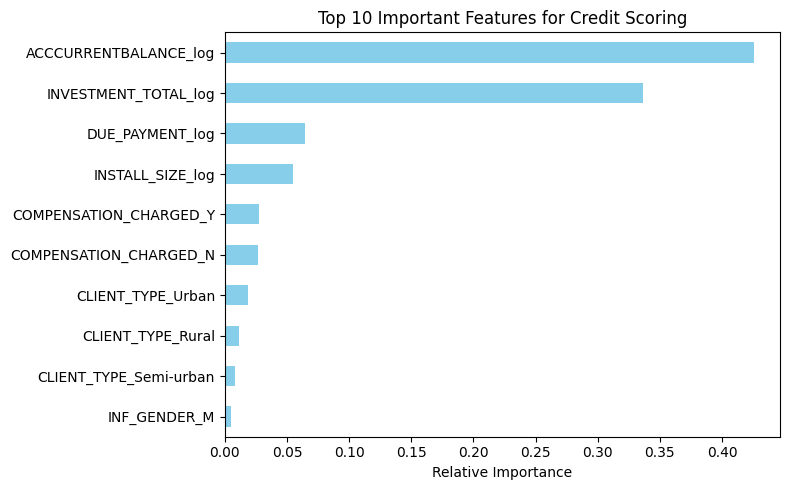

In [20]:


# Reconstruct feature names after One-Hot Encoding
ohe_feature_names = encoder.get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(ohe_feature_names)

# Compute Feature Importances
importances = pd.Series(
    model.feature_importances_, index=all_feature_names
).sort_values(ascending=False)

# Plot top 10 influential features
plt.figure(figsize=(8, 5))
importances.head(10).plot(kind="barh", color="skyblue").invert_yaxis()
plt.title("Top 10 Important Features for Credit Scoring")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

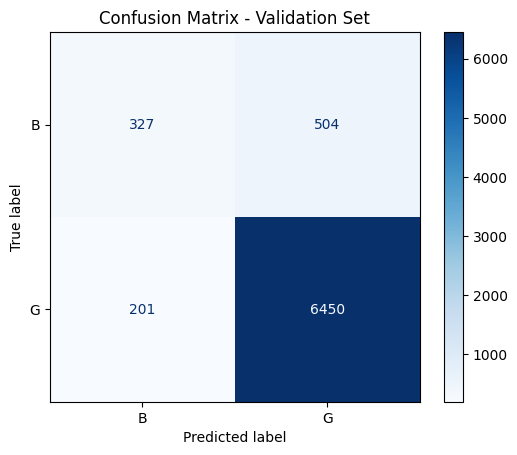

In [21]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap="Blues")
plt.title("Confusion Matrix - Validation Set")
plt.show()

In [22]:
df_test["PREDICTION"] = model.predict(X_test_full)
df_test["PROBABILITY_OF_DEFAULT"] = model.predict_proba(X_test_full)[:, 0]

# Export final submission CSV
df_test.to_csv("credit_scoring_predictions.csv", index=False)

In [23]:
import joblib

# Logistic Regression package
lr_package = {
    "model": lr_model,
    "encoder": encoder,
    "imputer": imputer,
    "cat_cols": cat_cols,
    "num_cols": num_cols
}

# Random Forest package
rf_package = {
    "model": model,
    "encoder": encoder,
    "imputer": imputer,
    "cat_cols": cat_cols,
    "num_cols": num_cols
}

joblib.dump(
    lr_package,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    rf_package,
    "../models/random_forest.pkl"
)

print("Models saved successfully!")

Models saved successfully!
